# First-Pitch Hit-Into-Play Prediction — Multi-Batter Study
## Which Model Best Captures the Minority Class Across the Top 100 Batters?

This notebook extends the single-batter pipeline into a cross-batter study. For each of the **top 100 batters by first-pitch hit-into-play rate** (min. 100 PA, 2024 season), we:

1. **Build** a batter-specific feature matrix with pitcher statistics and game-state context
2. **Train** six classifiers on 2024–mid-2025 data with SMOTE balancing
3. **Validate** each model on a held-out Aug–Sep 2025 dataset
4. **Record** per-batter minority-class metrics (precision, recall, F1 for `hit_into_play`)
5. **Aggregate** results across all 100 batters to identify the most consistent model

Visuals focus on minority-class performance, model consistency, and cross-batter variance.

---

## 1. Data Ingestion

In [1]:
# ── Imports & Configuration ──────────────────────────────────────────────────
import warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

from pybaseball import statcast, cache
cache.enable()
sys.path.insert(0, '.')
from statcast_loader import load_statcast

TRAIN_START  = '2024-03-28'
TRAIN_END    = '2025-08-01'
VAL_START    = '2025-08-02'
VAL_END      = '2025-09-28'
RANDOM_SEED   = 0
TEST_SIZE     = 0.25
TOP_N_BATTERS = 200
DECAY_RATE    = 0.004   # exp(-0.004 * 180) ≈ 0.49 → half-weight ~6 months ago

table       = load_statcast(TRAIN_START, TRAIN_END)
table_val   = load_statcast(VAL_START, VAL_END)
table_full  = load_statcast(TRAIN_START, VAL_END)   # pitcher stats drawn from full window

table['pitch_id']      = table.index
table_val['pitch_id']  = table_val.index
table_full['pitch_id'] = table_full.index

print(f'Training data  : {len(table):,} pitches  ({TRAIN_START} to {TRAIN_END})')
print(f'Validation data: {len(table_val):,} pitches  ({VAL_START} to {VAL_END})')

Loading from cache: statcast_20240328_20250801.parquet  (173.5 MB)
Loaded 1,250,482 pitches  (2024-03-28 → 2025-08-01)
Loading from cache: statcast_20250802_20250928.parquet  (36.1 MB)
Loaded 230,144 pitches  (2025-08-02 → 2025-09-28)
Loading from cache: statcast_20240328_20250928.parquet  (202.7 MB)
Loaded 1,480,626 pitches  (2024-03-28 → 2025-09-28)
Training data  : 1,250,482 pitches  (2024-03-28 to 2025-08-01)
Validation data: 230,144 pitches  (2025-08-02 to 2025-09-28)


In [2]:
# ── Load Sequential Context Features from Sidecar Parquets ──────────────────
# Generate these files once with:
#   python build_context_features.py <training_parquet>
#   python build_context_features.py <validation_parquet>
#
# Columns added:
#   pitcher_pitch_count_in_game     — pitches thrown by pitcher BEFORE this pitch
#   batter_prior_hip_count_in_game  — first-pitch HIPs by batter BEFORE this AB
#   pitcher_pitch_count_prior_game  — pitcher's total pitches in their prior game
#   batter_prior_game_hip_count     — batter's first-pitch HIPs in their prior game
import os

CONTEXT_COLS  = ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game',
                 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']
TRAIN_CONTEXT = f'statcast_{TRAIN_START.replace("-","")}_{TRAIN_END.replace("-","")}_context_features.parquet'
VAL_CONTEXT   = f'statcast_{VAL_START.replace("-","")}_{VAL_END.replace("-","")}_context_features.parquet'

if os.path.exists(TRAIN_CONTEXT):
    ctx_train = pd.read_parquet(TRAIN_CONTEXT)
    table = table.drop(columns=[c for c in CONTEXT_COLS if c in table.columns], errors='ignore')
    table = table.merge(ctx_train, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table.columns:
            table[col] = table[col].fillna(0).astype(int)
        else:
            table[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Training context features loaded: {len(ctx_train):,} rows')
else:
    print(f'WARNING: {TRAIN_CONTEXT} not found — running without context features.')
    for col in CONTEXT_COLS:
        table[col] = 0

if os.path.exists(VAL_CONTEXT):
    ctx_val = pd.read_parquet(VAL_CONTEXT)
    table_val = table_val.drop(columns=[c for c in CONTEXT_COLS if c in table_val.columns], errors='ignore')
    table_val = table_val.merge(ctx_val, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table_val.columns:
            table_val[col] = table_val[col].fillna(0).astype(int)
        else:
            table_val[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Validation context features loaded: {len(ctx_val):,} rows')
else:
    print(f'WARNING: {VAL_CONTEXT} not found — running without context features.')
    for col in CONTEXT_COLS:
        table_val[col] = 0

# Refresh pitch_id after merge
table['pitch_id']     = table.index
table_val['pitch_id'] = table_val.index


print(f'Context cols on table     : {[c for c in CONTEXT_COLS if c in table.columns]}')
print(f'Context cols on table_val : {[c for c in CONTEXT_COLS if c in table_val.columns]}')

Training context features loaded: 1,250,482 rows
Validation context features loaded: 230,144 rows
Context cols on table     : ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']
Context cols on table_val : ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']


## 2. Identify Top 100 Batters by First-Pitch Hit-Into-Play Rate (min. 100 PA)

In [3]:
# ── Selection criteria ───────────────────────────────────────────────────────
MIN_PA        = 100    # minimum first-pitch PA to qualify

# ── Identify first-pitch hit-into-play events ─────────────────────────────────
first_pitch_train = table[(table['balls'] == 0) & (table['strikes'] == 0)]
first_pitch_val   = table_val[(table_val['balls'] == 0) & (table_val['strikes'] == 0)]
first_pitch_full  = table_full[(table_full['balls'] == 0) & (table_full['strikes'] == 0)]

# Per-batter PA count and HIP count in training window
pa_counts  = first_pitch_train['batter'].value_counts()
hip_counts = (
    first_pitch_train[first_pitch_train['description'] == 'hit_into_play']
    ['batter'].value_counts()
)

# Build HIP rate table, enforce minimum PA, require presence in validation window
val_batters = set(first_pitch_val['batter'].unique())
hip_rate_df = (
    pd.DataFrame({'pa': pa_counts, 'hip': hip_counts})
    .fillna(0)
    .astype({'pa': int, 'hip': int})
    .assign(hip_rate=lambda df: df['hip'] / df['pa'])
    .loc[lambda df: (df['pa'] >= MIN_PA) & df.index.isin(val_batters)]
    .sort_values('hip_rate', ascending=False)
)

top_batter_ids = list(hip_rate_df.head(TOP_N_BATTERS).index)

print(f'Batters meeting criteria (>= {MIN_PA} PA, present in validation): {len(hip_rate_df):,}')
print(f'Top {TOP_N_BATTERS} selected.')
print(f'HIP rate range: {hip_rate_df["hip_rate"].iloc[len(top_batter_ids)-1]:.3f} '
      f'– {hip_rate_df["hip_rate"].iloc[0]:.3f}')

# ── Build batter name map via reverse lookup ──────────────────────────────────
# NOTE: Statcast's player_name column refers to the PITCHER, not the batter.
# We use pybaseball's playerid_reverse_lookup to get correct batter names.
from pybaseball import playerid_reverse_lookup

lookup_df = playerid_reverse_lookup(top_batter_ids, key_type='mlbam')
name_map  = {
    int(row['key_mlbam']): f"{row['name_first'].title()} {row['name_last'].title()}"
    for _, row in lookup_df.iterrows()
}

top10_df = pd.DataFrame({
    'batter_id': top_batter_ids[:10],
    'name':      [name_map.get(int(b), str(b)) for b in top_batter_ids[:10]],
    'train_PA':  [hip_rate_df.loc[b, 'pa']              for b in top_batter_ids[:10]],
    'hip_count': [hip_rate_df.loc[b, 'hip']             for b in top_batter_ids[:10]],
    'hip_rate':  [round(hip_rate_df.loc[b, 'hip_rate'], 3) for b in top_batter_ids[:10]],
})
print('\nTop 10 batters by first-pitch HIP rate (sanity check):')
print(top10_df.to_string(index=False))

Batters meeting criteria (>= 100 PA, present in validation): 432
Top 200 selected.
HIP rate range: 0.118 – 0.233

Top 10 batters by first-pitch HIP rate (sanity check):
 batter_id             name  train_PA  hip_count  hip_rate
    663968      Jake Mangum       279         65     0.233
    645302    Víctor Robles       370         77     0.208
    676391    Ernie Clement       874        178     0.204
    641584      Jake Fraley       579        112     0.193
    645305      Ali Sánchez       120         23     0.192
    695506   Jac Caglianone       167         32     0.192
    643289   Mauricio Dubón       712        136     0.191
    802415 Chandler Simpson       253         48     0.190
    673237      Yainer Diaz      1033        194     0.188
    683766   Christian Koss       123         23     0.187


## 3. Shared Feature-Engineering Constants

In [4]:
# ── All constants used inside the per-batter loop ────────────────────────────
NOT_IN_PLAY_OUTCOMES = [
    'called_strike', 'foul', 'swinging_strike', 'swinging_strike_blocked',
    'foul_tip', 'foul_bunt', 'missed_bunt', 'blocked_ball', 'ball',
    'bunt_foul_tip', 'automatic_strike', 'automatic_ball', 'intent_ball',
    'pitchout', 'hit_by_pitch',
]

PITCH_TYPES = ['FF','SI','SL','CH','FC','ST','CU','FS','KC','None',
               'SV','KN','FA','EP','FO','CS','SC','PO','UN']

pitcher_cols = (
    ['pitcher', 'strike_percent', 'swing_percent_on_strikes',
     'contact_percent_on_strikes', 'in_play_percent_on_strikes']
    + [f'{pt}_percent' for pt in PITCH_TYPES]
)

DROP_COLS_1 = [
    'game_date','spin_dir','batter','zone','spin_axis','spin_rate_deprecated',
    'break_angle_deprecated','break_length_deprecated','des','game_type','type',
    'hit_location','bb_type','balls','strikes','game_year','hc_x','hc_y',
    'tfs_deprecated','tfs_zulu_deprecated','umpire','sv_id','player_name',
    'hit_distance_sc','launch_speed','launch_angle',
    'fielder_2','fielder_3','fielder_4','fielder_5','fielder_6','fielder_7','fielder_8','fielder_9',
    'home_team','away_team','home_score','away_score','bat_score','fld_score',
    'post_away_score','post_home_score','post_bat_score','post_fld_score',
    'release_pos_y','delta_home_win_exp','delta_run_exp','bat_speed','swing_length',
    'estimated_slg_using_speedangle','delta_pitcher_run_exp','hyper_speed',
    'home_score_diff','home_win_exp','age_pit_legacy','age_bat_legacy',
    'age_pit','age_bat','pitcher_days_since_prev_game','batter_days_since_prev_game',
    'pitcher_days_until_next_game','batter_days_until_next_game','pitch_name',
]
DROP_COLS_2 = [
    'if_fielding_alignment','of_fielding_alignment','pitch_type','release_speed',
    'release_pos_x','release_pos_z','vx0','vy0','vz0','ax','ay','az','sz_top',
    'effective_speed','release_spin_rate','release_extension','sz_bot','pfx_x','pfx_z',
    'arm_angle','plate_x','plate_z','api_break_z_with_gravity','api_break_x_arm',
    'api_break_x_batter_in','estimated_ba_using_speedangle','estimated_woba_using_speedangle',
    'woba_value','woba_denom','babip_value','iso_value','launch_speed_angle',
]
DROP_COLS_3 = [
    'bat_score_diff','n_thruorder_pitcher','n_priorpa_thisgame_player_at_bat',
    'attack_angle','attack_direction','swing_path_tilt', 'miss_distance',
    'intercept_ball_minus_batter_pos_x_inches','intercept_ball_minus_batter_pos_y_inches',
]

CATEGORICAL_COLS  = ['p_throws', 'outs_when_up', 'stand', 'prev_pitch_result']
DROP_BEFORE_MODEL = ['pitcher', 'game_pk', 'inning', 'inning_topbot', 'pitch_number', 'pitch_id']

EVENT_MAP = {
    'hit_by_pitch': 'walk',    'intent_walk': 'walk',    'catcher_interf': 'walk',
    'home_run': 'extra_base_hit', 'triple': 'extra_base_hit', 'double': 'extra_base_hit',
    'force_out': 'field_out',  'fielders_choice': 'field_out',  'grounded_into_double_play': 'field_out',
    'double_play': 'field_out', 'fielders_choice_out': 'field_out', 'sac_bunt': 'field_out',
    'sac_fly': 'field_out',    'field_error': 'single',
    'strikeout_double_play': 'strikeout',
}

MODEL_NAMES = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'ANN']

print('Constants defined.')

Constants defined.


## 4. Helper Functions

In [5]:
# ── Feature engineering helpers ───────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

def compute_pitch_counts(desc_series):
    vc = desc_series.value_counts()
    return {k: vc.get(k, 0) for k in
            ['ball','called_strike','swinging_strike','foul','foul_bunt',
             'hit_into_play','blocked_ball','foul_tip','bunt_foul_tip',
             'swinging_strike_blocked','hit_by_pitch','missed_bunt',
             'pitchout','automatic_strike','automatic_ball','intent_ball']}

def build_pitcher_features(batter_rows, source_first_pitch):
    """Build pitcher feature DataFrame for pitchers seen by a batter."""
    pitchers = batter_rows['pitcher'].unique()
    pdf = pd.DataFrame(pitchers, columns=['pitcher'])
    for col in pitcher_cols[1:]:
        pdf[col] = 0.0
    for i in range(len(pdf)):
        pid = pdf['pitcher'].iloc[i]
        sel = source_first_pitch[source_first_pitch['pitcher'] == pid]
        c   = compute_pitch_counts(sel['description'])
        total_p   = sum(c.values())
        t_strikes = (c['called_strike'] + c['swinging_strike'] + c['foul'] +
                     c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] +
                     c['swinging_strike_blocked'] + c['missed_bunt'] +
                     c['bunt_foul_tip'] + c['automatic_strike'])
        t_contact = c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip']
        t_swings  = (c['swinging_strike'] + c['swinging_strike_blocked'] +
                     c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip'])
        if total_p > 0:
            pdf.at[i, 'strike_percent'] = t_strikes / total_p
            if t_strikes > 0:
                pdf.at[i, 'swing_percent_on_strikes']  = t_swings  / t_strikes
                pdf.at[i, 'contact_percent_on_strikes'] = t_contact / t_strikes
                pdf.at[i, 'in_play_percent_on_strikes'] = c['hit_into_play'] / t_strikes
        sel_pt   = sel['pitch_type'].fillna('None')
        pt_vc    = sel_pt.value_counts()
        total_pt = pt_vc.sum()
        if total_pt > 0:
            for pt in PITCH_TYPES:
                pdf.at[i, f'{pt}_percent'] = pt_vc.get(pt, 0) / total_pt
    return pdf

def add_game_state_context(merged_df, clean_df, source_table):
    """Add prev_pitch_result and prev_ab_pitch_count columns."""
    merged_df = merged_df.copy()
    merged_df['prev_pitch_result']   = ''
    merged_df['prev_ab_pitch_count'] = 0
    for i in range(len(clean_df)):
        select_id   = clean_df['pitch_id'].iloc[i]
        select_game = merged_df['game_pk'].iloc[i]
        select_inn  = merged_df['inning'].iloc[i]
        select_top  = merged_df['inning_topbot'].iloc[i]
        prev = source_table[source_table['pitch_id'] == (select_id + 1)]
        if prev.empty:
            merged_df.at[i, 'prev_pitch_result'] = 'start_of_game'
            continue
        prev_game = prev['game_pk'].values[0]
        prev_inn  = prev['inning'].values[0]
        prev_top  = prev['inning_topbot'].values[0]
        if prev_game != select_game:
            merged_df.at[i, 'prev_pitch_result'] = 'start_of_game'
        elif prev_inn != select_inn or prev_top != select_top:
            merged_df.at[i, 'prev_pitch_result'] = 'start_of_inning'
        else:
            merged_df.at[i, 'prev_pitch_result']   = prev['events'].values[0]
            merged_df.at[i, 'prev_ab_pitch_count'] = prev['pitch_number'].values[0]
    merged_df.replace(EVENT_MAP, inplace=True)
    desc_col = merged_df.pop('description')
    merged_df.insert(len(merged_df.columns), 'description', desc_col)
    return merged_df

def build_feature_matrix(batter_rows, pitcher_features, drop_table):
    """Clean columns, merge pitcher features, encode and return X, y."""
    batter_clean = (
        batter_rows
        .drop(columns=DROP_COLS_1, errors='ignore')
        .drop(columns=DROP_COLS_2, errors='ignore')
        .drop(columns=DROP_COLS_3, errors='ignore')
    )
    for base_col in ['on_1b', 'on_2b', 'on_3b']:
        batter_clean[base_col] = batter_clean[base_col].fillna(0)
        batter_clean.loc[batter_clean[base_col] > 0, base_col] = 1
    return batter_clean, pd.merge(batter_clean, pitcher_features, on='pitcher', how='inner')

def minority_class_metrics(y_true, y_pred, minority_label=1):
    """Return precision, recall, F1 specifically for the minority class."""
    prec = precision_score(y_true, y_pred, pos_label=minority_label, zero_division=0)
    rec  = recall_score(y_true, y_pred,    pos_label=minority_label, zero_division=0)
    f1   = f1_score(y_true, y_pred,        pos_label=minority_label, zero_division=0)
    return prec, rec, f1

print('Helper functions defined.')

Helper functions defined.


## 5. Install & Import Model Packages

In [6]:
import subprocess, sys, platform

# LightGBM
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '--quiet'])

# XGBoost (macOS requires libomp via conda: conda install -c conda-forge libomp)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '--quiet'])

# CatBoost
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '--quiet'])

import tensorflow as tf
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

print('All model packages ready.')
print(f'TensorFlow: {tf.__version__}')

All model packages ready.
TensorFlow: 2.18.0


## 6. Multi-Batter Training & Validation Loop

For each of the top 100 batters the loop:
- Builds batter-specific training and validation feature matrices
- Applies SMOTE, encodes, and scales
- Trains all six models and evaluates on the validation set
- Records **minority-class** precision, recall, and F1 (`hit_into_play`) per model

Batters with fewer than 10 validation first-pitch observations or no `hit_into_play` events in the validation window are skipped to avoid degenerate metrics.

In [7]:
# ── Per-batter results accumulator ───────────────────────────────────────────
# Structure: list of dicts with keys: batter_id, model, precision, recall, f1,
#            train_samples, val_samples, val_hit_into_play_count
all_results        = []
skipped            = []
dt_confusion_rows  = []   # Decision Tree confusion counts per batter

TRAIN_END_DT = pd.Timestamp(TRAIN_END)

for batter_idx, hitter_id in enumerate(top_batter_ids):
    batter_name = name_map.get(int(hitter_id), str(hitter_id))
    print(f'[{batter_idx+1:>3}/{TOP_N_BATTERS}] {batter_name} (id={hitter_id})', end=' ... ')

    try:
        # ── Training data for this batter ──────────────────────────────────────
        batter_train = first_pitch_train[first_pitch_train['batter'] == hitter_id].copy()
        batter_train_labeled = batter_train.drop('events', axis=1)
        for outcome in NOT_IN_PLAY_OUTCOMES:
            batter_train_labeled = batter_train_labeled.replace(outcome, 'not_in_play')

        # ── Compute decay weights before game_date is dropped ──────────────
        raw_dates = pd.to_datetime(batter_train_labeled['game_date'], errors='coerce')
        days_ago  = (TRAIN_END_DT - raw_dates).dt.days.clip(lower=0).fillna(0)
        weight_by_pid = pd.Series(
            np.exp(-DECAY_RATE * days_ago.values),
            index=batter_train_labeled['pitch_id'].values
        )

        pitcher_feats_train = build_pitcher_features(batter_train_labeled, first_pitch_train)
        batter_clean_train, merged_train = build_feature_matrix(
            batter_train_labeled, pitcher_feats_train, table
        )
        merged_train = add_game_state_context(merged_train, batter_clean_train, table)

        # ── Align weights to rows that survived the merge ──────────────────
        aligned_weights = (
            weight_by_pid.reindex(merged_train['pitch_id'].values)
            .fillna(weight_by_pid.mean())
            .values
        )

        dataset_train = merged_train.drop(columns=DROP_BEFORE_MODEL, errors='ignore')
        X_raw = dataset_train.iloc[:, :-1]
        y_raw = dataset_train.iloc[:,  -1]

        # ── Print input feature columns (fires once for the first batter) ────
        if batter_idx == 0:
            print(f'\nInput feature columns ({len(X_raw.columns)}):')
            print(sorted(X_raw.columns.tolist()))

        ct = ColumnTransformer(
            transformers=[('enc', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLS)],
            remainder='passthrough'
        )
        X_enc = ct.fit_transform(X_raw)
        le    = LabelEncoder()
        y_enc = le.fit_transform(y_raw)

        # Determine minority label index (hit_into_play)
        classes = list(le.classes_)
        if 'hit_into_play' not in classes:
            skipped.append((hitter_id, batter_name, 'no hit_into_play in training'))
            print('SKIP (no hit_into_play in train)')
            continue
        minority_label = classes.index('hit_into_play')

        # SMOTE
        smote      = SMOTE(sampling_strategy='minority', random_state=42)
        X_sm, y_sm = smote.fit_resample(X_enc, y_enc)

        # ── Propagate decay weights through SMOTE ──────────────────────────
        minority_mask   = (y_enc == minority_label)
        mean_minority_w = aligned_weights[minority_mask].mean() if minority_mask.any() else 1.0
        n_synthetic     = X_sm.shape[0] - X_enc.shape[0]
        sm_weights      = np.concatenate([
            aligned_weights,
            np.full(n_synthetic, mean_minority_w),
        ])

        from sklearn.model_selection import train_test_split
        X_tr, X_te, y_tr, y_te, w_tr, w_te = train_test_split(
            X_sm, y_sm, sm_weights, test_size=TEST_SIZE, random_state=RANDOM_SEED
        )
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        # ── Validation data for this batter ────────────────────────────────────
        batter_val = first_pitch_val[first_pitch_val['batter'] == hitter_id].copy()
        if len(batter_val) < 10:
            skipped.append((hitter_id, batter_name, f'only {len(batter_val)} val rows'))
            print(f'SKIP (only {len(batter_val)} val rows)')
            continue

        batter_val_labeled = batter_val.drop('events', axis=1)
        for outcome in NOT_IN_PLAY_OUTCOMES:
            batter_val_labeled = batter_val_labeled.replace(outcome, 'not_in_play')

        # Check minority class exists in validation
        if 'hit_into_play' not in batter_val_labeled['description'].values:
            skipped.append((hitter_id, batter_name, 'no hit_into_play in validation'))
            print('SKIP (no hit_into_play in val)')
            continue

        pitcher_feats_val = build_pitcher_features(batter_val_labeled, first_pitch_full)
        batter_clean_val, merged_val = build_feature_matrix(
            batter_val_labeled, pitcher_feats_val, table_val
        )
        merged_val = add_game_state_context(merged_val, batter_clean_val, table_val)

        dataset_val_b = merged_val.drop(columns=DROP_BEFORE_MODEL, errors='ignore')
        X_val_raw = dataset_val_b.iloc[:, :-1]
        y_val_raw = dataset_val_b.iloc[:,  -1]

        X_val_enc = ct.transform(X_val_raw)
        le_val    = LabelEncoder()
        y_val_enc = le_val.fit_transform(y_val_raw)
        X_val_sc  = sc.transform(X_val_enc)

        # Map minority label through validation encoder
        val_classes   = list(le_val.classes_)
        if 'hit_into_play' not in val_classes:
            skipped.append((hitter_id, batter_name, 'hit_into_play missing in val encoder'))
            print('SKIP')
            continue
        val_minority_label = val_classes.index('hit_into_play')
        val_hip_count      = int((y_val_enc == val_minority_label).sum())

        # ── Train & evaluate each model ────────────────────────────────────────
        models = {
            'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_SEED),
            'Random Forest': RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=RANDOM_SEED),
            'XGBoost':       XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                           subsample=0.8, colsample_bytree=0.8,
                                           use_label_encoder=False, eval_metric='logloss',
                                           random_state=RANDOM_SEED, verbosity=0),
            'LightGBM':      lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                                subsample=0.8, colsample_bytree=0.8,
                                                is_unbalance=True, random_state=RANDOM_SEED, verbose=-1),
            'CatBoost':      CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                                                auto_class_weights='Balanced',
                                                random_seed=RANDOM_SEED, verbose=0),
        }

        for model_name, clf in models.items():
            clf.fit(X_tr, y_tr, sample_weight=w_tr)
            y_pred = clf.predict(X_val_sc)
            prec, rec, f1 = minority_class_metrics(y_val_enc, y_pred, val_minority_label)
            all_results.append({
                'batter_id':           hitter_id,
                'batter_name':         batter_name,
                'model':               model_name,
                'precision_hip':       prec,
                'recall_hip':          rec,
                'f1_hip':              f1,
                'train_samples':       X_sm.shape[0],
                'val_samples':         X_val_sc.shape[0],
                'val_hip_count':       val_hip_count,
            })

            # ── Capture Decision Tree confusion counts for the HIP table ──────
            if model_name == 'Decision Tree':
                m = val_minority_label   # index for hit_into_play
                n = 1 - m               # index for not_in_play (binary)
                # True Positive  : predicted HIP,     actual HIP
                tp = int(((y_pred == m) & (y_val_enc == m)).sum())
                # False Positive : predicted HIP,     actual not-HIP
                fp = int(((y_pred == m) & (y_val_enc == n)).sum())
                # False Negative : predicted not-HIP, actual HIP
                fn = int(((y_pred == n) & (y_val_enc == m)).sum())
                dt_confusion_rows.append({
                    'batter_id':                     hitter_id,
                    'batter_name':                   batter_name,
                    'predicted_hip_result_hip':       tp,
                    'predicted_hip_result_not_hip':   fp,
                    'predicted_not_hip_result_hip':   fn,
                    'val_hip_total':                  val_hip_count,
                    'val_samples':                    X_val_sc.shape[0],
                })

        # ── ANN ────────────────────────────────────────────────────────────────
        X_tr_ann  = X_tr.astype('float32')
        y_tr_ann  = y_tr.astype('float32')
        w_tr_ann  = w_tr.astype('float32')
        ann = tf.keras.models.Sequential([
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(8,  activation='relu'),
            tf.keras.layers.Dense(4,  activation='relu'),
            tf.keras.layers.Dense(1,  activation='sigmoid'),
        ])
        ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        ann.fit(X_tr_ann, y_tr_ann,
                sample_weight=w_tr_ann,
                batch_size=min(100, len(X_tr_ann)),
                epochs=100, validation_split=0.1, verbose=0)
        y_pred_ann = (ann.predict(X_val_sc.astype('float32'), verbose=0) > 0.5).astype(int).flatten()
        prec, rec, f1 = minority_class_metrics(y_val_enc, y_pred_ann, val_minority_label)
        all_results.append({
            'batter_id':     hitter_id,
            'batter_name':   batter_name,
            'model':         'ANN',
            'precision_hip': prec,
            'recall_hip':    rec,
            'f1_hip':        f1,
            'train_samples': X_sm.shape[0],
            'val_samples':   X_val_sc.shape[0],
            'val_hip_count': val_hip_count,
        })

        print(f'OK  (train={X_sm.shape[0]}, val={X_val_sc.shape[0]}, val_HIP={val_hip_count})')

    except Exception as e:
        skipped.append((hitter_id, batter_name, str(e)))
        print(f'ERROR: {e}')

results_df = pd.DataFrame(all_results)
results_df.to_csv('multi_batter_results.csv', index=False)

print(f'\n=== Loop complete ===')
print(f'Batters processed : {results_df["batter_id"].nunique()}')
print(f'Batters skipped   : {len(skipped)}')
print(f'Total result rows : {len(results_df)}')

[  1/200] Jake Mangum (id=663968) ... 
Input feature columns (37):
['CH_percent', 'CS_percent', 'CU_percent', 'EP_percent', 'FA_percent', 'FC_percent', 'FF_percent', 'FO_percent', 'FS_percent', 'KC_percent', 'KN_percent', 'None_percent', 'PO_percent', 'SC_percent', 'SI_percent', 'SL_percent', 'ST_percent', 'SV_percent', 'UN_percent', 'at_bat_number', 'bat_win_exp', 'batter_prior_game_hip_count', 'batter_prior_hip_count_in_game', 'contact_percent_on_strikes', 'in_play_percent_on_strikes', 'on_1b', 'on_2b', 'on_3b', 'outs_when_up', 'p_throws', 'pitcher_pitch_count_in_game', 'pitcher_pitch_count_prior_game', 'prev_ab_pitch_count', 'prev_pitch_result', 'stand', 'strike_percent', 'swing_percent_on_strikes']
OK  (train=428, val=157, val_HIP=21)
OK  (train=586, val=68, val_HIP=13) ... 
OK  (train=1392, val=181, val_HIP=33)
OK  (train=934, val=38, val_HIP=1)... 
SKIP (only 4 val rows)(id=645305) ... 
OK  (train=270, val=71, val_HIP=6)6) ... 
OK  (train=1152, val=131, val_HIP=15)... 
OK  (train

## 7. Decision Tree — Per-Batter Confusion Table

For each batter, three confusion counts are recorded for the `hit_into_play` class on the validation set:

| Column | Meaning |
|--------|--------|
| `predicted_hip_result_hip` | Correctly predicted HIP (True Positive) |
| `predicted_hip_result_not_hip` | Predicted HIP but actual was not-HIP (False Positive) |
| `predicted_not_hip_result_hip` | Predicted not-HIP but actual was HIP (False Negative) |

In [8]:
# ── Build and save Decision Tree confusion table ─────────────────────────────
dt_confusion_df = (
    pd.DataFrame(dt_confusion_rows)
    .sort_values('batter_name')
    .reset_index(drop=True)
)

dt_confusion_df['recall_hip'] = (
    dt_confusion_df['predicted_hip_result_hip'] /
    dt_confusion_df['val_hip_total'].replace(0, float('nan'))
).round(3)

dt_confusion_df['precision_hip'] = (
    dt_confusion_df['predicted_hip_result_hip'] /
    (dt_confusion_df['predicted_hip_result_hip'] + dt_confusion_df['predicted_hip_result_not_hip'])
    .replace(0, float('nan'))
).round(3)

dt_confusion_df.to_csv('dt_hip_confusion_per_batter_final_4.csv', index=False)

print(f'Saved: dt_hip_confusion_per_batter.csv  ({len(dt_confusion_df)} batters)')
print()
print(dt_confusion_df.to_string(index=False))

Saved: dt_hip_confusion_per_batter.csv  (192 batters)

 batter_id         batter_name  predicted_hip_result_hip  predicted_hip_result_not_hip  predicted_not_hip_result_hip  val_hip_total  val_samples  recall_hip  precision_hip
    691182        Adael Amador                         4                             2                             2              6           16       0.667          0.667
    680718      Addison Barger                         5                            32                            15             20          175       0.250          0.135
    682663     Agustín Ramírez                         5                            36                            22             27          225       0.185          0.122
    702176          Alan Roden                         2                             4                             3              5           35       0.400          0.333
    664761           Alec Bohm                         3                            2

## 8. Aggregate Results

Compute mean and median minority-class metrics across all batters for each model.

In [9]:
# ── Summary statistics per model ─────────────────────────────────────────────
agg = (
    results_df
    .groupby('model')[['precision_hip', 'recall_hip', 'f1_hip']]
    .agg(['mean', 'median', 'std'])
    .round(4)
)
agg.columns = ['_'.join(c) for c in agg.columns]
agg = agg.sort_values('f1_hip_mean', ascending=False)

print('Minority-class (hit_into_play) performance — aggregated across batters')
print('=' * 80)
print(agg.to_string())
print('=' * 80)

# Flat summary for easy reading
flat = (
    results_df
    .groupby('model')[['precision_hip', 'recall_hip', 'f1_hip']]
    .mean()
    .round(4)
    .sort_values('f1_hip', ascending=False)
    .rename(columns={'precision_hip': 'Precision', 'recall_hip': 'Recall', 'f1_hip': 'F1'})
)
print('\nMean minority-class metrics (sorted by F1):')
print(flat.to_string())

Minority-class (hit_into_play) performance — aggregated across batters
               precision_hip_mean  precision_hip_median  precision_hip_std  recall_hip_mean  recall_hip_median  recall_hip_std  f1_hip_mean  f1_hip_median  f1_hip_std
model                                                                                                                                                                 
Decision Tree              0.1423                0.1310             0.1041           0.2329             0.2297          0.1576       0.1703         0.1633      0.1134
ANN                        0.1356                0.1250             0.1086           0.1973             0.1791          0.1511       0.1520         0.1481      0.1092
Random Forest              0.1479                0.1429             0.1137           0.1446             0.1277          0.1216       0.1378         0.1312      0.1033
XGBoost                    0.1518                0.1429             0.1587           0.0927   

## 9. Visualisations

All plots focus on `hit_into_play` (minority class) performance across batters.

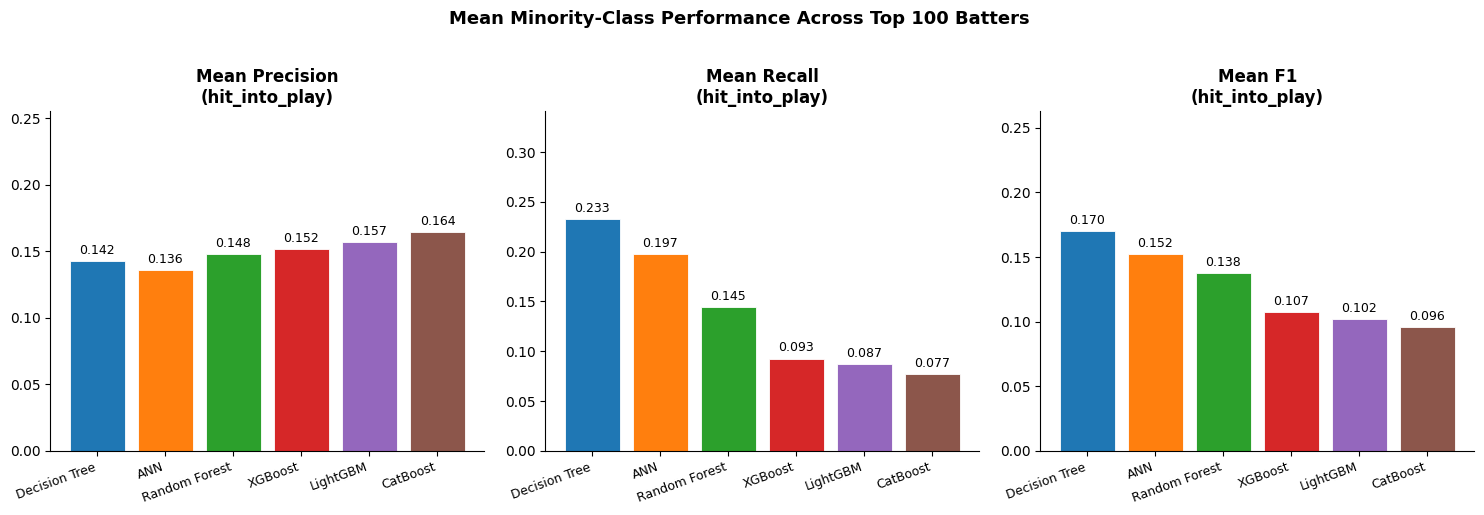

In [10]:
# ── 8a. Mean minority-class metrics bar chart ────────────────────────────────
model_order = list(flat.index)   # sorted by mean F1

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
palette = sns.color_palette('tab10', len(model_order))

for ax, metric, label in zip(
    axes,
    ['Precision', 'Recall', 'F1'],
    ['Mean Precision\n(hit_into_play)', 'Mean Recall\n(hit_into_play)', 'Mean F1\n(hit_into_play)']
):
    vals = [flat.loc[m, metric] for m in model_order]
    bars = ax.bar(model_order, vals, color=palette, edgecolor='white', linewidth=0.6)
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, min(1.1, max(vals) * 1.25 + 0.05))
    ax.set_xticklabels(model_order, rotation=20, ha='right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Mean Minority-Class Performance Across Top 100 Batters',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mean_minority_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

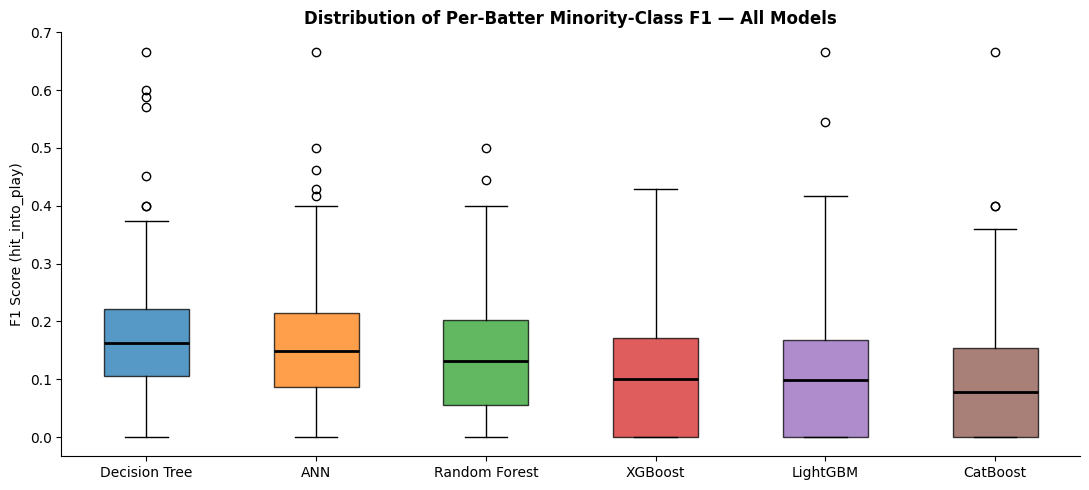

In [11]:
# ── 8b. Box plots — distribution of per-batter F1 for hit_into_play ─────────
fig, ax = plt.subplots(figsize=(11, 5))
plot_data = [results_df[results_df['model'] == m]['f1_hip'].values for m in model_order]
bp = ax.boxplot(plot_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(model_order, fontsize=10)
ax.set_ylabel('F1 Score (hit_into_play)')
ax.set_title('Distribution of Per-Batter Minority-Class F1 — All Models',
             fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('f1_distribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

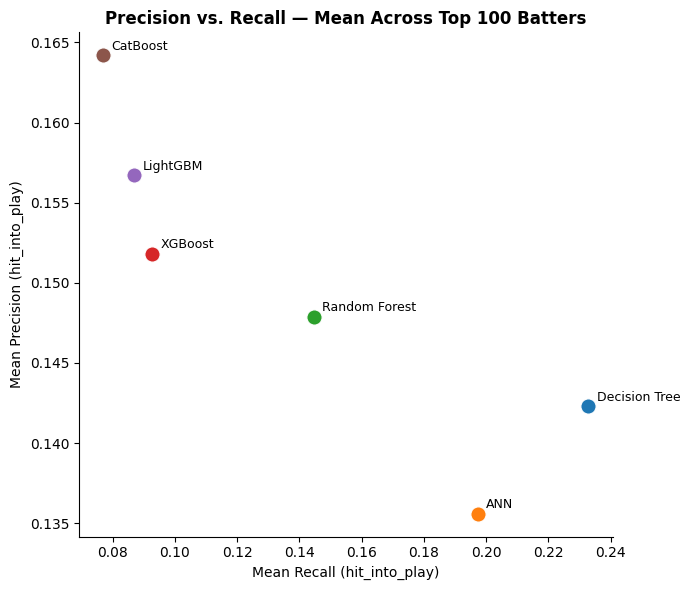

In [12]:
# ── 8c. Precision vs Recall scatter — mean per model ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for model, color in zip(model_order, palette):
    row = flat.loc[model]
    ax.scatter(row['Recall'], row['Precision'], s=120, color=color,
               label=model, zorder=5, edgecolors='white', linewidths=0.8)
    ax.annotate(model, (row['Recall'], row['Precision']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Mean Recall (hit_into_play)')
ax.set_ylabel('Mean Precision (hit_into_play)')
ax.set_title('Precision vs. Recall — Mean Across Top 100 Batters',
             fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('precision_recall_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

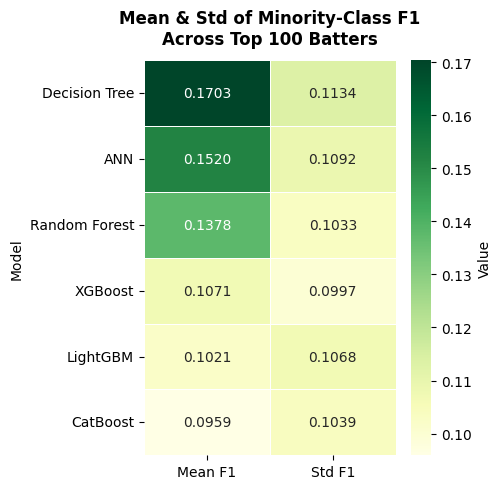

In [13]:
# ── 8d. Heatmap — mean F1 by model, with std as annotation ──────────────────
heat_mean = results_df.groupby('model')['f1_hip'].mean().reindex(model_order)
heat_std  = results_df.groupby('model')['f1_hip'].std().reindex(model_order)

heat_df = pd.DataFrame({
    'Mean F1': heat_mean.values,
    'Std F1':  heat_std.values,
}, index=model_order)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    heat_df, annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Value'}
)
ax.set_title('Mean & Std of Minority-Class F1\nAcross Top 100 Batters',
             fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('f1_mean_std_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

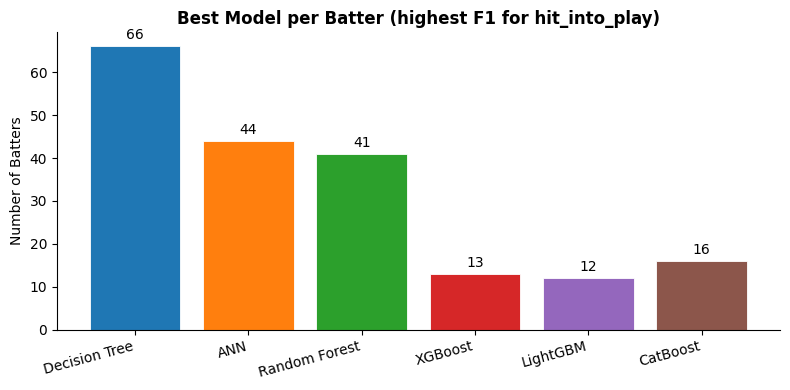

Win counts (best F1 per batter):
model
Decision Tree    66
ANN              44
Random Forest    41
XGBoost          13
LightGBM         12
CatBoost         16


In [14]:
# ── 8e. Win-rate: how often each model achieves the highest per-batter F1 ────
winner_counts = (
    results_df
    .loc[results_df.groupby('batter_id')['f1_hip'].idxmax()]
    ['model']
    .value_counts()
    .reindex(model_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(winner_counts.index, winner_counts.values,
              color=palette, edgecolor='white', linewidth=0.6)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel('Number of Batters')
ax.set_title('Best Model per Batter (highest F1 for hit_into_play)',
             fontweight='bold')
ax.set_xticklabels(winner_counts.index, rotation=15, ha='right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('win_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Win counts (best F1 per batter):')
print(winner_counts.to_string())

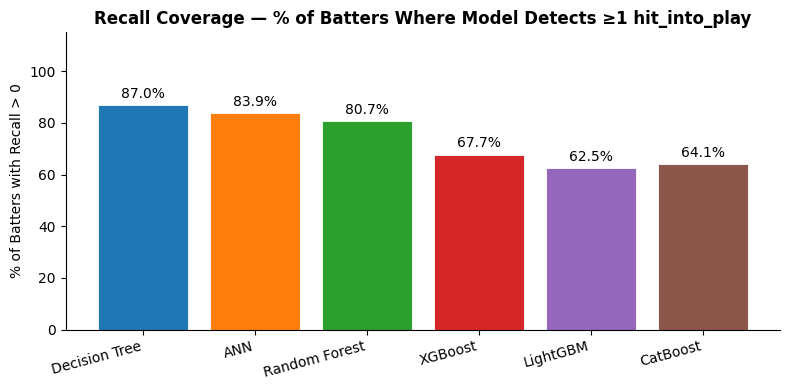

In [15]:
# ── 8f. Recall consistency — % of batters where recall > 0 ──────────────────
# A model that never predicts the minority class gives recall=0; 
# this plot shows how reliably each model finds *any* hit_into_play events.
recall_coverage = (
    results_df
    .groupby('model')['recall_hip']
    .apply(lambda x: (x > 0).mean() * 100)
    .reindex(model_order)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(recall_coverage.index, recall_coverage.values,
              color=palette, edgecolor='white', linewidth=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_ylabel('% of Batters with Recall > 0')
ax.set_ylim(0, 115)
ax.set_title('Recall Coverage — % of Batters Where Model Detects ≥1 hit_into_play',
             fontweight='bold')
ax.set_xticklabels(recall_coverage.index, rotation=15, ha='right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('recall_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Skipped Batters Report

In [16]:
if skipped:
    skip_df = pd.DataFrame(skipped, columns=['batter_id', 'name', 'reason'])
    print(f'{len(skip_df)} batters skipped:')
    print(skip_df.to_string(index=False))
else:
    print('No batters were skipped.')

8 batters skipped:
 batter_id          name          reason
    645305   Ali Sánchez only 4 val rows
    686676     Korey Lee only 9 val rows
    668845  Aaron Schunk only 4 val rows
    689172  Brett Wisely only 9 val rows
    542932     Jon Berti only 1 val rows
    691777     Max Muncy only 7 val rows
    665804  Miguel Amaya only 3 val rows
    669450 Cooper Hummel only 1 val rows
